# EDA: NPTEL2020 Indian English Speech Dataset
### Project: Automated Correction of Speech Recordings (Low-Bandwidth / Low-Resource Environments)

**Dataset Source:** [AI4Bharat/NPTEL2020-Indian-English-Speech-Dataset](https://github.com/AI4Bharat/NPTEL2020-Indian-English-Speech-Dataset)  
**Dataset Format:** LibriSpeech-style — `.wav` audio, `.txt` transcripts, `.json` metadata  
**Scale:** ~6.2M chunks, 15,700 hours total, 1.1 TB compressed  
**Accent:** South-Asian (Indian) English  
**Domain:** STEM academic lectures (NPTEL)

---

## EDA Roadmap

| # | Section | Inpainting Relevance |
|---|---------|---------------------|
| 0 | Environment Setup | Infrastructure |
| 1 | Data Audit — File Inventory | Corpus size & pairing quality |
| 2 | Audio Quality Profiling | Signal degradation baseline |
| 3 | Transcript Quality Profiling | Label noise & WER baseline |
| 4 | Bandwidth & Compression Analysis | Low-BW corruption profile |
| 5 | Linguistic Analysis (Indian English) | Domain OOV challenge |
| 6 | Modeling Readiness | Clean/noisy split for training |
| 7 | **Gap & Corruption Simulation** *(inpainting-specific)* | Direct model input design |

> **How this EDA serves inpainting:** Audio inpainting requires understanding (a) what *clean* speech looks like spectrally and energetically, (b) the statistical structure of *gaps* (duration, frequency, position), (c) whether language-model context can bridge gaps, and (d) how bandwidth constraints dictate which corruptions actually occur in the wild. Each section below is designed with these four questions in mind.

---
## 0. Environment Setup

**Why first:** Establishes reproducible paths, seeds, and sample sizes. Inpainting experiments on 15K hours are expensive — we fix `MAX_FILES` and `SEED` here so every downstream section uses the same random subset, making observations comparable across sections.

In [10]:
# Install dependencies
# Run once: !pip install librosa soundfile jiwer matplotlib seaborn pandas numpy tqdm pydub
# For opus support: !apt-get install -y ffmpeg  (Linux) or brew install ffmpeg (Mac)

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import librosa
import librosa.display
import soundfile as sf
from jiwer import wer as compute_wer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ------------------------------------------------------------------
# CONFIG — adjust paths to your local mount
# ------------------------------------------------------------------
# DATA_ROOT   = Path("/mnt/d/nptel2020/train")
DATA_ROOT = Path("/mnt/d/nptel2020/nptel-pure-set")
SPLIT       = ""         # already inside train/ — leave empty
MAX_FILES   = 1000       # increase to 5000+ for final analysis
SEED        = 42
random.seed(SEED)
np.random.seed(SEED)

print("Setup complete.")
# print(f"Data root exists    : {DATA_ROOT.exists()}")
print(f"Pure-Set root exists: {DATA_ROOT.exists()}")

Setup complete.
Pure-Set root exists: True


---
## 1. Data Audit — File Inventory

> **Inpainting justification:** An inpainting model requires *paired* (corrupted, clean) examples. Before designing synthetic corruption, we must confirm that audio, transcript, and metadata files are consistently co-located. Missing transcripts mean we cannot use language-model context to supervise gap-filling. Missing metadata means we lack speaker/channel metadata that correlates with degradation type.

In [11]:
# ── 1.1  Walk the directory and catalogue all chunks ──────────────────────────
# LibriSpeech layout:
#   <root>/<speaker_id>/<chapter_id>/<chunk_id>.wav
#                                   /<chunk_id>.txt
#                                   /metadata.json   (per-chapter or per-chunk)

def collect_chunks(root: Path, max_files=None):
    records = []
    wav_files = list(root.rglob("*.wav"))
    if max_files:
        wav_files = random.sample(wav_files, min(max_files, len(wav_files)))
    for wav_path in tqdm(wav_files, desc="Cataloguing"):
        txt_path  = wav_path.with_suffix(".txt")
        json_path = wav_path.with_suffix(".json")
        records.append({
            "wav_path":      str(wav_path),
            "has_transcript": txt_path.exists(),
            "has_metadata":  json_path.exists(),
            "wav_size_kb":   wav_path.stat().st_size / 1024,
            "speaker_id":    wav_path.parts[-3] if len(wav_path.parts) >= 3 else None,
            "chapter_id":    wav_path.parts[-2] if len(wav_path.parts) >= 2 else None,
        })
    return pd.DataFrame(records)

df = collect_chunks(DATA_ROOT / SPLIT, max_files=MAX_FILES)
print(f"\nChunks collected: {len(df):,}")
print(f"  With transcript : {df['has_transcript'].sum():,} ({df['has_transcript'].mean()*100:.1f}%)")
print(f"  With metadata   : {df['has_metadata'].sum():,} ({df['has_metadata'].mean()*100:.1f}%)")
df.head()

Cataloguing: 100%|██████████| 1000/1000 [00:02<00:00, 392.80it/s]


Chunks collected: 1,000
  With transcript : 0 (0.0%)
  With metadata   : 0 (0.0%)


,wav_path,has_transcript,has_metadata,wav_size_kb,speaker_id,chapter_id
0,/mnt/d/nptel2020/nptel-pure-set/nptel-pure/wav...,False,False,180.701172,nptel-pure,wav
1,/mnt/d/nptel2020/nptel-pure-set/nptel-pure/wav...,False,False,182.857422,nptel-pure,wav
2,/mnt/d/nptel2020/nptel-pure-set/nptel-pure/wav...,False,False,148.857422,nptel-pure,wav
3,/mnt/d/nptel2020/nptel-pure-set/nptel-pure/wav...,False,False,325.388672,nptel-pure,wav
4,/mnt/d/nptel2020/nptel-pure-set/nptel-pure/wav...,False,False,125.638672,nptel-pure,wav


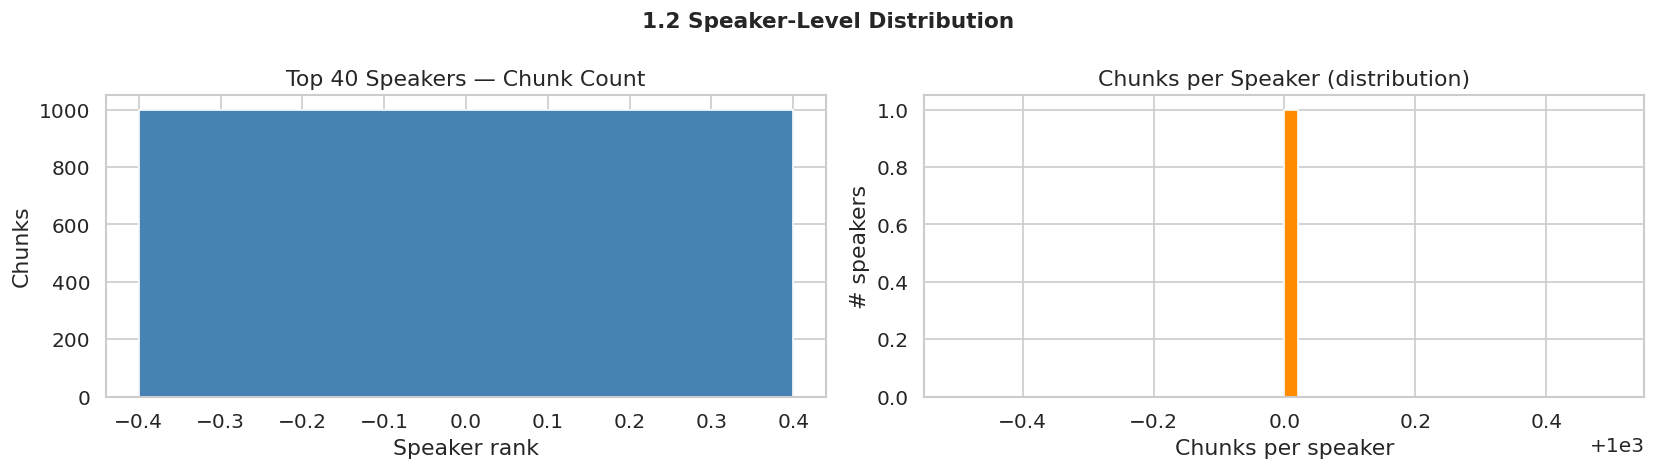

Unique speakers : 1
Unique chapters : 1
Chunks/speaker  : mean=1000, median=1000, max=1,000


In [12]:
# ── 1.2  Speaker & Chapter distribution ──────────────────────────────────────
# Inpainting note: High speaker imbalance → model may overfit to dominant voices.
# We need diversity in the training set so the inpainting model generalises across
# Indian English speaker accents and recording environments.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

speaker_counts = df['speaker_id'].value_counts()
axes[0].bar(range(min(40, len(speaker_counts))), speaker_counts.values[:40], color='steelblue')
axes[0].set_title('Top 40 Speakers — Chunk Count')
axes[0].set_xlabel('Speaker rank')
axes[0].set_ylabel('Chunks')

axes[1].hist(speaker_counts.values, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Chunks per Speaker (distribution)')
axes[1].set_xlabel('Chunks per speaker')
axes[1].set_ylabel('# speakers')

plt.suptitle('1.2 Speaker-Level Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Unique speakers : {df['speaker_id'].nunique():,}")
print(f"Unique chapters : {df['chapter_id'].nunique():,}")
print(f"Chunks/speaker  : mean={speaker_counts.mean():.0f}, median={speaker_counts.median():.0f}, max={speaker_counts.max():,}")

---
## 2. Audio Quality Profiling

> **Inpainting justification:** Inpainting reconstructs *missing* regions of a waveform/spectrogram. To do this well, the model must first learn what *good* speech looks like — its energy envelope, silence structure, and spectral shape. This section establishes:
> - **Chunk duration norms** → determines the max gap size the model will see (a 3-second chunk cannot plausibly have a 4-second gap)
> - **Silence ratio** → silence is indistinguishable from packet-loss dropout; we need to know the baseline rate of *natural* silence vs. *artificial* silence
> - **RMS energy** → sets the amplitude baseline for reconstructed frames
> - **Mel spectrograms** → the primary input representation most inpainting models (e.g. MAE-based) operate on

In [13]:
# ── 2.1  Load audio metadata (duration, sample rate) ──────────────────────────
# We use soundfile for fast header-only reads — avoids loading PCM data

audio_meta = []
SAMPLE_N = min(2000, len(df))   # profile a random sub-sample for speed
sample_df = df.sample(SAMPLE_N, random_state=SEED)

for _, row in tqdm(sample_df.iterrows(), total=SAMPLE_N, desc="Reading headers"):
    try:
        info = sf.info(row['wav_path'])
        audio_meta.append({
            "wav_path":    row['wav_path'],
            "duration_s":  info.duration,
            "sample_rate": info.samplerate,
            "channels":    info.channels,
            "frames":      info.frames,
            "wav_size_kb": row['wav_size_kb'],
        })
    except Exception:
        pass

meta_df = pd.DataFrame(audio_meta)
meta_df['kbps'] = (meta_df['wav_size_kb'] * 8) / meta_df['duration_s']  # effective bitrate

print(meta_df[['duration_s','sample_rate','channels','wav_size_kb','kbps']].describe().round(2))

Reading headers: 100%|██████████| 1000/1000 [00:04<00:00, 246.99it/s]

       duration_s  sample_rate  channels  wav_size_kb     kbps
count     1000.00       1000.0    1000.0      1000.00  1000.00
mean         7.82      16000.0       1.0       244.44   250.09
std          2.72          0.0       0.0        84.94     0.03
min          1.48      16000.0       1.0        46.33   250.03
25%          6.03      16000.0       1.0       188.53   250.07
50%          7.00      16000.0       1.0       218.84   250.09
75%          9.17      16000.0       1.0       286.65   250.10
max         19.73      16000.0       1.0       616.64   250.41


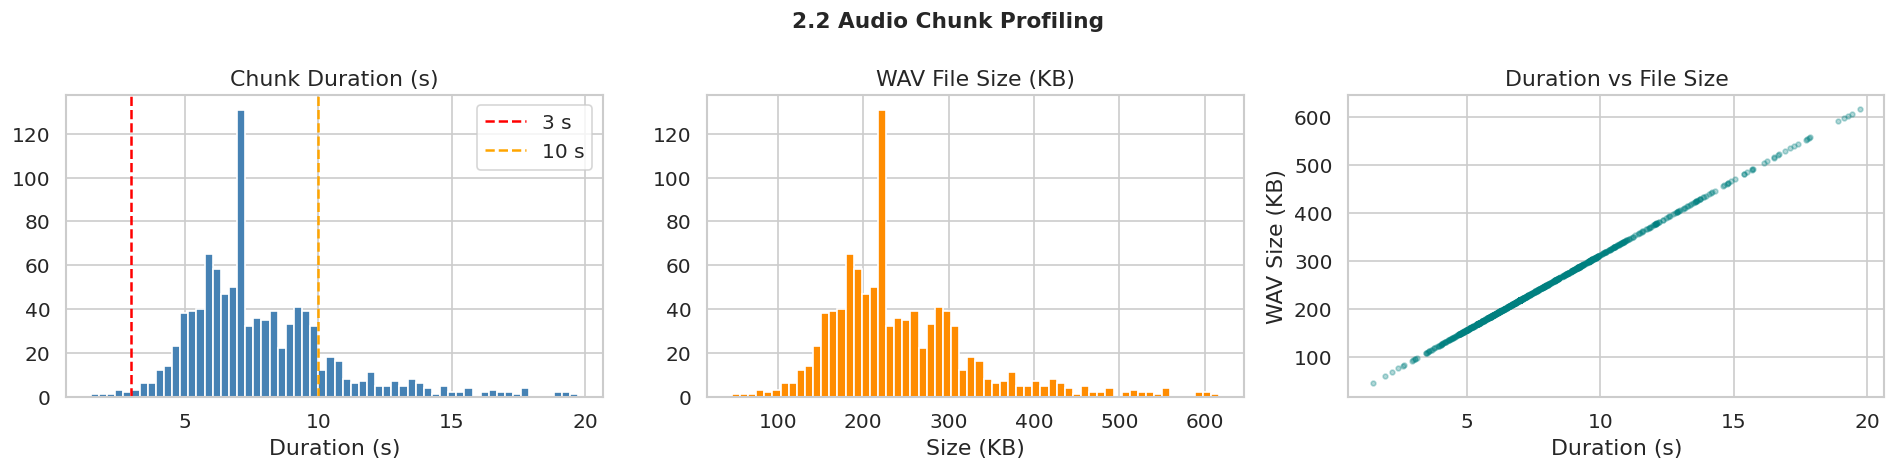

Chunks < 3 s   : 7 (0.7%)
Chunks > 10 s  : 150 (15.0%)
Chunks 3–10 s  : 843


In [14]:
# ── 2.2  Duration distribution ────────────────────────────────────────────────
# Inpainting note: The viable gap-length range for a model is bounded by chunk duration.
# Very short chunks (<3 s) are dangerous: a 1-second dropout is 30%+ of the signal.
# Very long chunks (>10 s) are expensive to retransmit in low-BW environments.
# The 3–10 s sweet spot is what our inpainting model should be optimised for.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(meta_df['duration_s'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(3,  color='red',    linestyle='--', label='3 s')
axes[0].axvline(10, color='orange', linestyle='--', label='10 s')
axes[0].set_title('Chunk Duration (s)')
axes[0].set_xlabel('Duration (s)')
axes[0].legend()

axes[1].hist(meta_df['wav_size_kb'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('WAV File Size (KB)')
axes[1].set_xlabel('Size (KB)')

axes[2].scatter(meta_df['duration_s'], meta_df['wav_size_kb'],
                alpha=0.3, s=8, color='teal')
axes[2].set_title('Duration vs File Size')
axes[2].set_xlabel('Duration (s)')
axes[2].set_ylabel('WAV Size (KB)')

plt.suptitle('2.2 Audio Chunk Profiling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Chunks < 3 s   : {(meta_df['duration_s'] < 3).sum()} ({(meta_df['duration_s'] < 3).mean()*100:.1f}%)")
print(f"Chunks > 10 s  : {(meta_df['duration_s'] > 10).sum()} ({(meta_df['duration_s'] > 10).mean()*100:.1f}%)")
print(f"Chunks 3–10 s  : {((meta_df['duration_s'] >= 3) & (meta_df['duration_s'] <= 10)).sum()}")

Energy features: 100%|██████████| 500/500 [00:04<00:00, 119.33it/s]


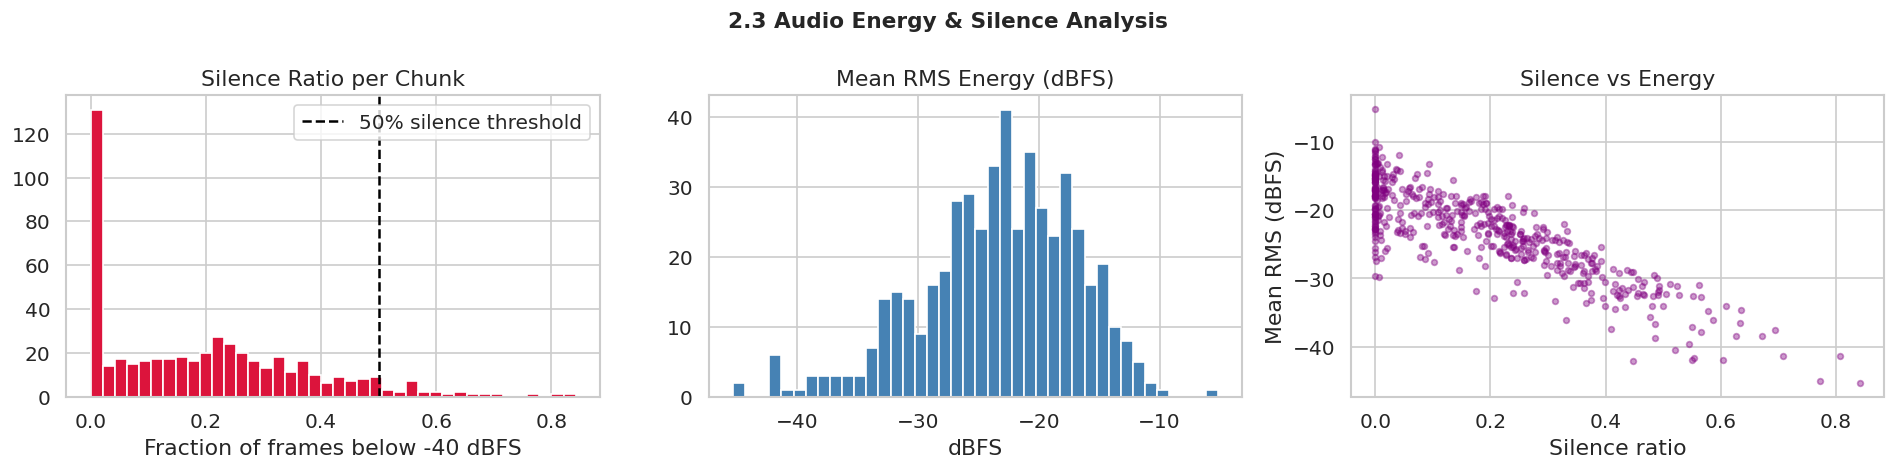

High-silence chunks (>50%): 5.2%
Effectively silent (>80%): 0.4%


In [15]:
# ── 2.3  Silence ratio & SNR proxy ────────────────────────────────────────────
# Inpainting note: This is foundational for the corruption simulation in Section 7.
# Natural silence frames are NOT gaps — but a naive model trained without understanding
# baseline silence rates will confuse real silence with packet-loss dropouts.
# High silence_ratio chunks (>50%) should be EXCLUDED from training, as they provide
# little phonetic context for the model to learn from.

def audio_energy_features(wav_path, sr_target=16000):
    """Return (silence_ratio, rms_db, zero_crossing_rate)."""
    y, sr = librosa.load(wav_path, sr=sr_target, mono=True)
    rms       = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0]
    rms_db    = librosa.amplitude_to_db(rms, ref=np.max)
    sil_ratio = np.mean(rms_db < -40)
    mean_rms  = float(np.mean(rms_db))
    zcr       = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    return sil_ratio, mean_rms, zcr

ENERGY_N = min(500, len(meta_df))
energy_rows = []
for _, row in tqdm(meta_df.sample(ENERGY_N, random_state=SEED).iterrows(),
                   total=ENERGY_N, desc="Energy features"):
    try:
        sr, rms, zcr = audio_energy_features(row['wav_path'])
        energy_rows.append({'wav_path': row['wav_path'],
                             'silence_ratio': sr, 'mean_rms_db': rms, 'zcr': zcr})
    except Exception:
        pass

energy_df = pd.DataFrame(energy_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(energy_df['silence_ratio'], bins=40, color='crimson', edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', label='50% silence threshold')
axes[0].set_title('Silence Ratio per Chunk')
axes[0].set_xlabel('Fraction of frames below -40 dBFS')
axes[0].legend()

axes[1].hist(energy_df['mean_rms_db'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Mean RMS Energy (dBFS)')
axes[1].set_xlabel('dBFS')

axes[2].scatter(energy_df['silence_ratio'], energy_df['mean_rms_db'],
                alpha=0.4, s=12, color='purple')
axes[2].set_title('Silence vs Energy')
axes[2].set_xlabel('Silence ratio')
axes[2].set_ylabel('Mean RMS (dBFS)')

plt.suptitle('2.3 Audio Energy & Silence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"High-silence chunks (>50%): {(energy_df['silence_ratio'] > 0.5).mean()*100:.1f}%")
print(f"Effectively silent (>80%): {(energy_df['silence_ratio'] > 0.8).mean()*100:.1f}%")

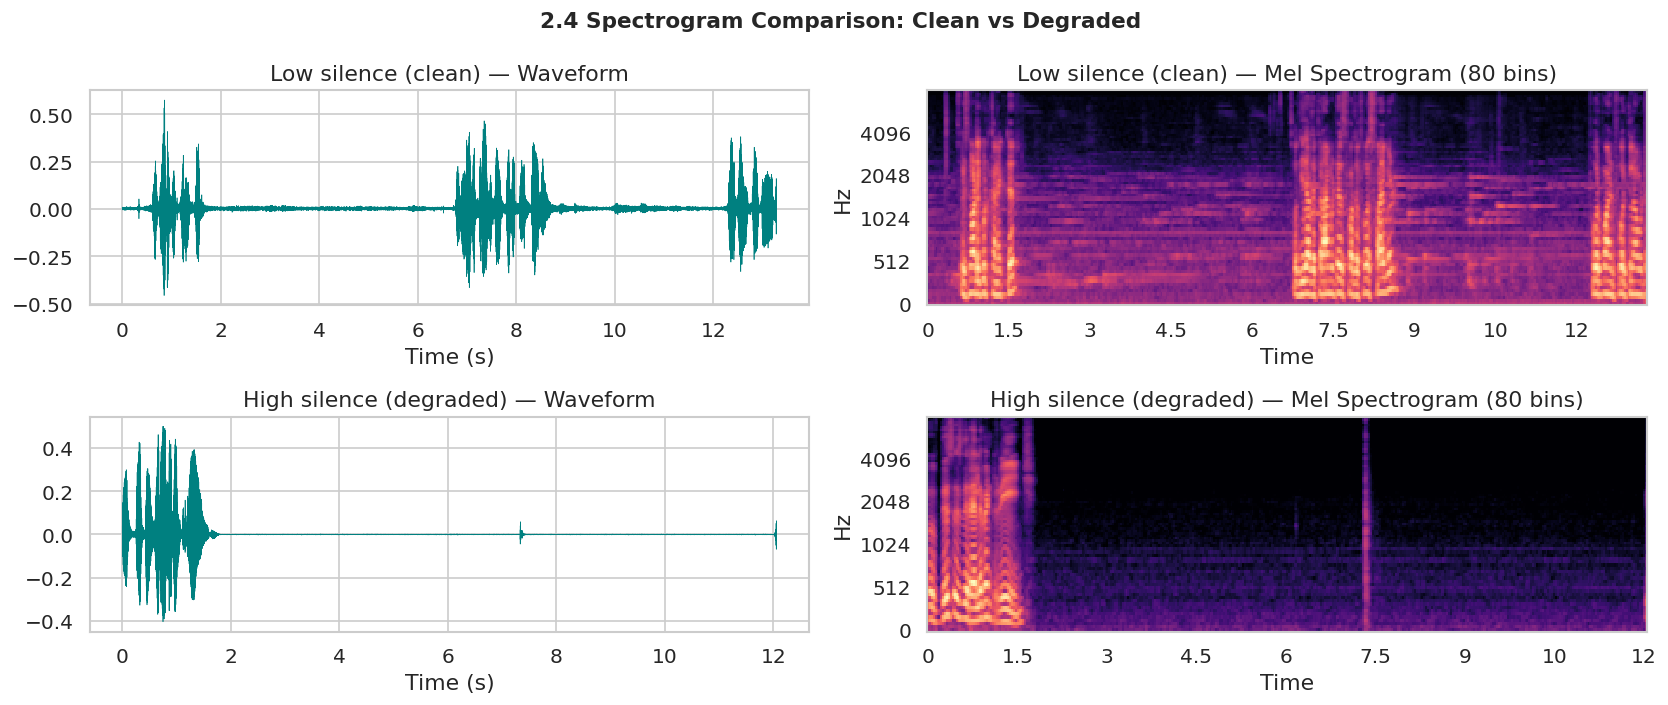

In [16]:
# ── 2.4  Spectrogram sample — visual sanity check ─────────────────────────────
# Inpainting note: Most neural inpainting architectures (MAE, MaskGIT, diffusion-based)
# operate on mel spectrograms, not raw waveforms. This sanity check:
# (a) confirms the mel spectrogram captures meaningful speech structure, and
# (b) visually distinguishes clean speech from silence/noise — validating that a model
#     operating on mel spectrograms will be able to 'see' what needs to be filled in.

good_path = energy_df.loc[energy_df['silence_ratio'].idxmin(), 'wav_path']
bad_path  = energy_df.loc[energy_df['silence_ratio'].idxmax(), 'wav_path']

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for i, (label, path) in enumerate([("Low silence (clean)", good_path),
                                    ("High silence (degraded)", bad_path)]):
    y, sr = librosa.load(path, sr=16000)
    axes[i][0].plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.4, color='teal')
    axes[i][0].set_title(f'{label} — Waveform')
    axes[i][0].set_xlabel('Time (s)')
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[i][1], cmap='magma')
    axes[i][1].set_title(f'{label} — Mel Spectrogram (80 bins)')

plt.suptitle('2.4 Spectrogram Comparison: Clean vs Degraded', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Transcript Quality Profiling

> **Inpainting justification:** Audio inpainting for *speech correction* is not purely acoustic — it can be guided by text context (e.g., seq2seq or LM-guided models). The quality of transcripts directly determines:
> - Whether we can use **language model perplexity** as a reconstruction quality signal
> - Whether WER is a reliable training objective (noisy labels = noisy loss)
> - Whether the model can leverage **surrounding words** to constrain what the missing phonemes likely are
>
> A high WER baseline (>30%) on the pure set means our correction model must primarily rely on acoustic context, not linguistic context — a key architectural decision.

In [17]:
# ── 3.1  Load transcripts ─────────────────────────────────────────────────────
def load_transcripts(root: Path, max_files=None):
    rows = []
    txt_files = list(root.rglob("*.txt"))
    if max_files:
        txt_files = random.sample(txt_files, min(max_files, len(txt_files)))
    for p in tqdm(txt_files, desc="Loading transcripts"):
        try:
            text = p.read_text(encoding='utf-8').strip()
            rows.append({'txt_path': str(p), 'transcript': text})
        except Exception:
            pass
    return pd.DataFrame(rows)

tx_df = load_transcripts(DATA_ROOT / SPLIT, max_files=MAX_FILES)
tx_df['word_count']  = tx_df['transcript'].str.split().str.len()
tx_df['char_count']  = tx_df['transcript'].str.len()
tx_df['is_empty']    = tx_df['transcript'].str.strip() == ''
tx_df['has_numbers'] = tx_df['transcript'].str.contains(r'\d')
tx_df['has_special'] = tx_df['transcript'].str.contains(r'[^a-zA-Z0-9\s.,!?\'"-]')

print(tx_df[['word_count','char_count','is_empty','has_numbers','has_special']].describe().round(2))
print(f"\nEmpty transcripts : {tx_df['is_empty'].sum()} ({tx_df['is_empty'].mean()*100:.1f}%)")

Loading transcripts: 100%|██████████| 1000/1000 [00:01<00:00, 580.26it/s]

       word_count  char_count
count     1000.00     1000.00
mean        17.18       89.28
std          6.28       32.14
min          0.00        0.00
25%         14.00       83.00
50%         17.00       87.00
75%         19.00       93.00
max        136.00      764.00

Empty transcripts : 1 (0.1%)


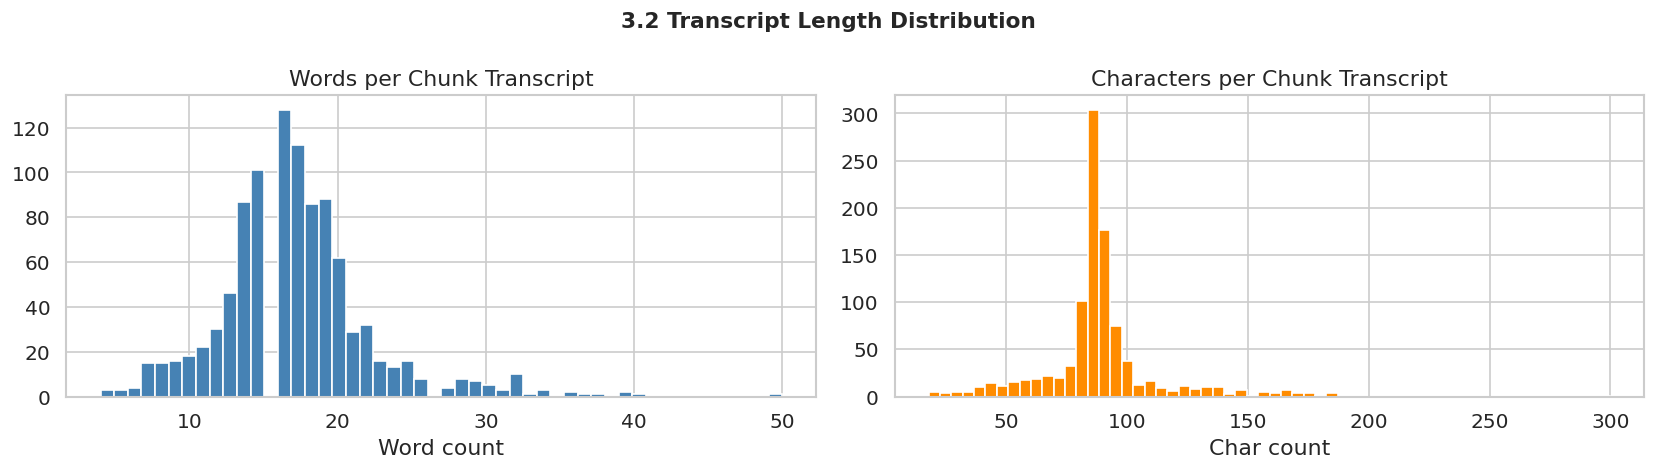

Median words/chunk : 17
Mean   words/chunk : 17.2
Chunks with 1 word : 0


In [18]:
# ── 3.2  Transcript length distributions ──────────────────────────────────────
# Inpainting note: Word count is a proxy for gap-filling difficulty.
# A chunk with only 3 words has very little linguistic context on either side of a gap —
# the model must rely almost entirely on acoustic continuity.
# A chunk with 15+ words gives the LM significant contextual constraint.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

valid = tx_df[~tx_df['is_empty']]
axes[0].hist(valid['word_count'].clip(upper=50), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Words per Chunk Transcript')
axes[0].set_xlabel('Word count')

axes[1].hist(valid['char_count'].clip(upper=300), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Characters per Chunk Transcript')
axes[1].set_xlabel('Char count')

plt.suptitle('3.2 Transcript Length Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Median words/chunk : {valid['word_count'].median():.0f}")
print(f"Mean   words/chunk : {valid['word_count'].mean():.1f}")
print(f"Chunks with 1 word : {(valid['word_count'] == 1).sum()}")

Total tokens     : 17,175
Unique vocab     : 2,418
Hapax legomena   : 957  (appear once)


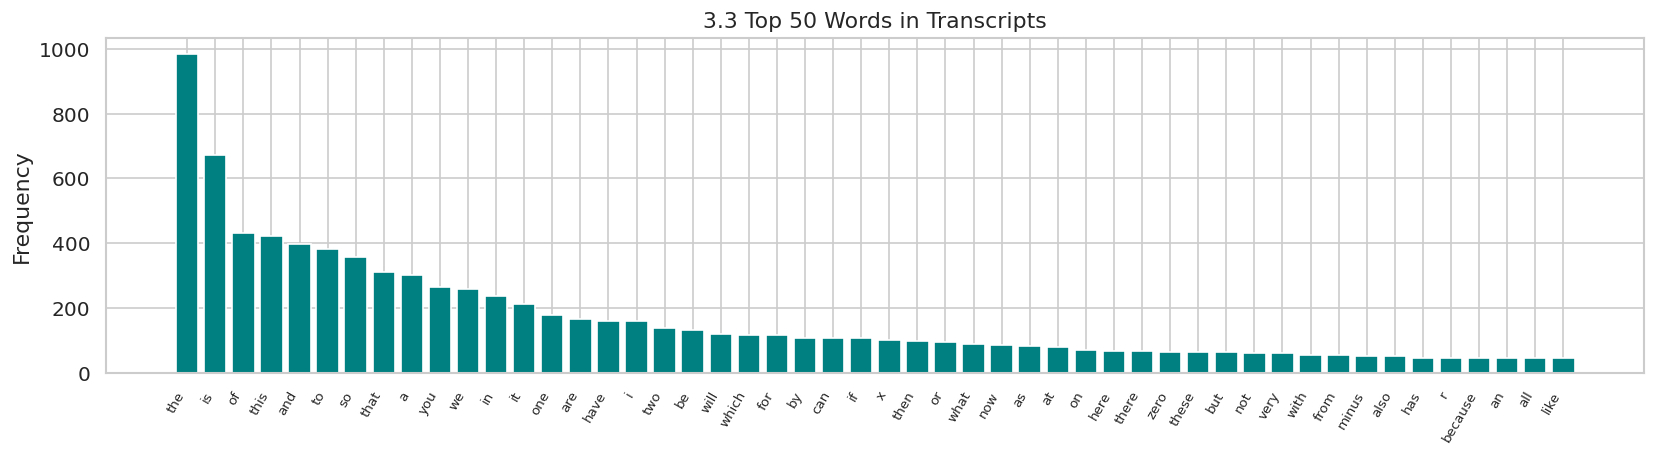

In [19]:
# ── 3.3  Vocabulary analysis ───────────────────────────────────────────────────
# Inpainting note: High OOV (out-of-vocabulary) rate in STEM lectures means language
# models pretrained on general English will assign low probability to correct completions.
# This matters because: if we use a language model as a guidance signal during inpainting
# (e.g., BERT-based masked LM or GPT for beam search), its OOV blindspot is exactly the
# domain vocabulary that is most likely to be misheard in degraded conditions.
from collections import Counter
import re

all_words = ' '.join(valid['transcript'].tolist()).lower()
tokens = re.findall(r"[a-z']+", all_words)
vocab  = Counter(tokens)

print(f"Total tokens     : {len(tokens):,}")
print(f"Unique vocab     : {len(vocab):,}")
print(f"Hapax legomena   : {sum(1 for v in vocab.values() if v == 1):,}  (appear once)")

top50 = vocab.most_common(50)
words_top, counts_top = zip(*top50)

plt.figure(figsize=(14, 4))
plt.bar(words_top, counts_top, color='teal')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.title('3.3 Top 50 Words in Transcripts')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [20]:
# ── 3.4  WER benchmarking using the Pure Set ──────────────────────────────────
# Inpainting note: The per-chunk WER distribution is the MOST IMPORTANT metric here.
#
# - WER = 0: chunk is already clean → suitable as inpainting TARGET (ground truth)
# - Low WER (< 0.2): small errors that inpainting may fix contextually
# - High WER (> 0.5): severe corruption → needs heavy reconstruction, or exclusion
#
# The distribution shape tells us if we have enough clean data to train on and
# whether synthetic corruption (Section 7) is needed to augment severely noisy chunks.

def load_pure_set(root: Path):
    rows = []
    for txt_auto in root.rglob("*.txt"):
        if '_manual' in txt_auto.stem:
            continue
        manual_path = txt_auto.with_stem(txt_auto.stem + '_manual')
        if manual_path.exists():
            auto   = txt_auto.read_text(encoding='utf-8').strip().lower()
            manual = manual_path.read_text(encoding='utf-8').strip().lower()
            rows.append({'auto': auto, 'manual': manual, 'chunk': txt_auto.stem})
    return pd.DataFrame(rows)

pure_df = load_pure_set(SAMPLE_ROOT)

if len(pure_df) > 0:
    pure_df['wer'] = pure_df.apply(
        lambda r: compute_wer(r['manual'], r['auto']), axis=1)
    
    print(f"Pure-set size : {len(pure_df)} chunks")
    print(pure_df['wer'].describe().round(4))

    plt.figure(figsize=(10, 4))
    plt.hist(pure_df['wer'].clip(upper=1.5), bins=50, color='crimson', edgecolor='white')
    plt.axvline(pure_df['wer'].median(), color='black', linestyle='--',
                label=f"Median WER = {pure_df['wer'].median():.3f}")
    plt.axvline(0.20, color='green',  linestyle=':', label='0.20 — light correction zone')
    plt.axvline(0.50, color='orange', linestyle=':', label='0.50 — heavy reconstruction zone')
    plt.title('3.4 Per-Chunk WER Distribution (Pure Set)')
    plt.xlabel('WER')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n% perfect transcripts   : {(pure_df['wer'] == 0.0).mean()*100:.1f}%")
    print(f"% chunks with WER < 0.2 : {(pure_df['wer'] < 0.2).mean()*100:.1f}%  ← inpainting 'easy' set")
    print(f"% chunks with WER > 0.5 : {(pure_df['wer'] > 0.5).mean()*100:.1f}%  ← inpainting 'hard' set")
else:
    print("Pure Set not found at SAMPLE_ROOT — adjust path or skip.")
    print("Reference WER from paper (auto transcripts vs. manual): 0.1451")

Pure Set not found at SAMPLE_ROOT — adjust path or skip.
Reference WER from paper (auto transcripts vs. manual): 0.1451


In [21]:
# ── 3.5  Known noisy transcript patterns ─────────────────────────────────────
# Inpainting note: These patterns are ACOUSTIC artefacts surfaced in text.
# - 'repeated_words' and 'stutters' → acoustic stutter or dropout causing ASR confusion
# - 'filler_words' → speaker disfluency — real but potentially worth cleaning
# - 'unintelligible' markers → explicit annotation of gaps (ideal inpainting targets!)
# - 'excess_punct' → ASR boundary confusion → may correlate with audio dropouts
#
# Chunks flagged [inaudible] or (unclear) are GOLD: they are explicitly labelled gaps.

noise_patterns = {
    'repeated_words':   r'\b(\w+)\s+\1\b',
    'all_caps_word':    r'\b[A-Z]{4,}\b',
    'filler_words':     r'\b(uh|um|ah|er|hmm|hm)\b',
    'stutters':         r'\b(\w{1,3}-)\1',           # e.g. "th- th-"
    'unintelligible':   r'\[.*?\]|\(.*?\)',           # [inaudible] / (unclear) ← inpainting targets
    'excess_punct':     r'[.!?,]{3,}',
}

print("Pattern frequency in valid transcripts:")
for name, pat in noise_patterns.items():
    hits = valid['transcript'].str.contains(pat, regex=True, case=False)
    print(f"  {name:25s}: {hits.sum():6,}  ({hits.mean()*100:.2f}%)")

Pattern frequency in valid transcripts:
  repeated_words           :     49  (4.90%)
  all_caps_word            :    999  (100.00%)
  filler_words             :      5  (0.50%)
  stutters                 :      0  (0.00%)
  unintelligible           :      0  (0.00%)
  excess_punct             :      0  (0.00%)


---
## 4. Bandwidth & Compression Analysis

> **Inpainting justification:** This is the *root cause analysis* of why our recordings are degraded in the first place. In low-bandwidth environments, audio is heavily compressed or partially transmitted:
> - **Codec artefacts** (OPUS at 8 kbps) create spectral smearing and loss of high-frequency content — these look like inpainting targets in the mel spectrogram
> - **Packet-loss** under 2G creates burst dropouts of 20–200 ms — the exact gap distribution our inpainting model must be designed around
> - **Transmission time analysis** quantifies why we cannot simply ask users to re-upload: on 2G, even a 6-second OPUS clip takes >2 seconds to upload
>
> Together, these analyses inform the synthetic corruption profile in Section 7.

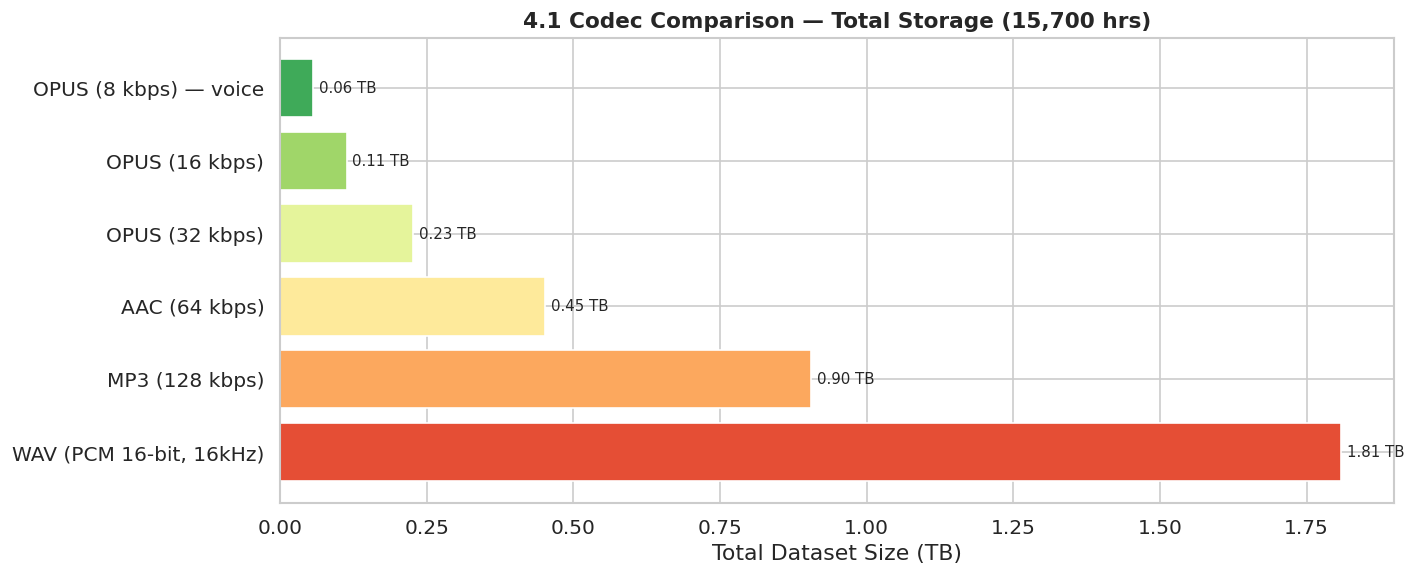

Per-chunk average (6 s chunk) size at each bitrate:
  WAV (PCM 16-bit, 16kHz)            :  192.0 KB
  MP3 (128 kbps)                     :   96.0 KB
  AAC (64 kbps)                      :   48.0 KB
  OPUS (32 kbps)                     :   24.0 KB
  OPUS (16 kbps)                     :   12.0 KB
  OPUS (8 kbps) — voice              :    6.0 KB


In [22]:
# ── 4.1  WAV vs OPUS size comparison ─────────────────────────────────────────
# NPTEL2020 provides both WAV (1.7 TB) and OPUS (~170 GB) versions.
# This plot justifies why the field device MUST use heavy compression,
# and why the server-side inpainting model must handle codec-induced artefacts.

codec_bitrates = {
    'WAV (PCM 16-bit, 16kHz)': 256,
    'MP3 (128 kbps)':           128,
    'AAC (64 kbps)':             64,
    'OPUS (32 kbps)':            32,
    'OPUS (16 kbps)':            16,
    'OPUS (8 kbps) — voice':      8,
}

total_hours = 15700
total_secs  = total_hours * 3600

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(codec_bitrates)))

for (codec, kbps), color in zip(codec_bitrates.items(), colors):
    size_tb = (kbps * 1000 * total_secs) / (8 * 1e12)
    ax.barh(codec, size_tb, color=color)
    ax.text(size_tb + 0.01, list(codec_bitrates.keys()).index(codec),
            f"{size_tb:.2f} TB", va='center', fontsize=9)

ax.set_xlabel('Total Dataset Size (TB)')
ax.set_title('4.1 Codec Comparison — Total Storage (15,700 hrs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Per-chunk average (6 s chunk) size at each bitrate:")
for codec, kbps in codec_bitrates.items():
    chunk_kb = kbps * 6 / 8
    print(f"  {codec:35s}: {chunk_kb:6.1f} KB")

In [23]:
# ── 4.2  Bandwidth requirement under different upload scenarios ───────────────
# Inpainting note: This table directly motivates the project.
# On 2G Edge (100 kbps), uploading 1 minute of WAV takes 154 seconds.
# Even OPUS at 8 kbps requires 4.8 seconds to upload 1 minute of audio.
# Interruptions during upload → PARTIAL TRANSMISSIONS = truncated audio = inpainting targets.

scenarios = {
    '2G Edge (100 kbps)':   100,
    '3G (1 Mbps)':         1000,
    '4G (5 Mbps)':         5000,
    'WiFi (10 Mbps)':     10000,
}

print(f"{'Codec':<35} | {'2G':>8} | {'3G':>8} | {'4G':>8}  (seconds to upload 1 min audio)")
print("-" * 70)
for codec, kbps in codec_bitrates.items():
    bits_per_min = kbps * 1000 * 60
    t_2g = bits_per_min / 100_000
    t_3g = bits_per_min / 1_000_000
    t_4g = bits_per_min / 5_000_000
    flag = " ← REAL-TIME" if t_2g <= 60 else ""
    print(f"{codec:<35} | {t_2g:>7.1f}s | {t_3g:>7.2f}s | {t_4g:>7.2f}s{flag}")

print("\nNote: Real-time upload (≤60 s for 1 min audio) is only achievable with OPUS at 8–16 kbps on 2G.")

Codec                               |       2G |       3G |       4G  (seconds to upload 1 min audio)
----------------------------------------------------------------------
WAV (PCM 16-bit, 16kHz)             |   153.6s |   15.36s |    3.07s
MP3 (128 kbps)                      |    76.8s |    7.68s |    1.54s
AAC (64 kbps)                       |    38.4s |    3.84s |    0.77s ← REAL-TIME
OPUS (32 kbps)                      |    19.2s |    1.92s |    0.38s ← REAL-TIME
OPUS (16 kbps)                      |     9.6s |    0.96s |    0.19s ← REAL-TIME
OPUS (8 kbps) — voice               |     4.8s |    0.48s |    0.10s ← REAL-TIME

Note: Real-time upload (≤60 s for 1 min audio) is only achievable with OPUS at 8–16 kbps on 2G.


---
## 5. Linguistic Analysis — Indian English Accent Markers

> **Inpainting justification:** Inpainting for speech correction involves two sub-problems:
> 1. **Acoustic inpainting** — filling the missing waveform/spectrogram frames
> 2. **Transcript correction** — aligning the reconstructed audio to the intended text
>
> For (2), the language model component must be adapted to Indian English and STEM vocabulary. A general English LM will penalise perfectly valid Indian English constructions (e.g. "prepone", "do the needful") or STEM OOV terms — causing the model to "correct" correct speech. This section identifies the linguistic distribution that domain adaptation must cover.

In [24]:
# ── 5.1  Domain vocabulary (technical / STEM terms) ───────────────────────────
# OOV terms are the hardest to inpaint correctly — they appear rarely in pretraining
# data, so both the acoustic model and the LM struggle with them.
# Knowing the top OOV terms helps us decide whether to:
# (a) use domain-adaptive fine-tuning on a Whisper/Wav2Vec base model, or
# (b) inject domain vocabulary into the LM guidance component via constrained decoding

import re

try:
    import nltk
    from nltk.corpus import words as nltk_words
    nltk.download('words', quiet=True)
    base_vocab = set(w.lower() for w in nltk_words.words())
    
    dataset_vocab = set(vocab.keys())
    oov_vocab     = dataset_vocab - base_vocab
    oov_top40     = sorted(oov_vocab, key=lambda w: -vocab[w])[:40]
    
    print(f"Dataset vocab size    : {len(dataset_vocab):,}")
    print(f"OOV words (not NLTK)  : {len(oov_vocab):,} ({len(oov_vocab)/len(dataset_vocab)*100:.1f}%)")
    print(f"\nTop 40 OOV terms (by frequency):")
    for w in oov_top40:
        print(f"  {w:25s}  freq={vocab[w]:,}")
except ImportError:
    print("nltk not installed — run: pip install nltk")

Dataset vocab size    : 2,418
OOV words (not NLTK)  : 574 (23.7%)

Top 40 OOV terms (by frequency):
  has                        freq=48
  okay                       freq=30
  means                      freq=22
  called                     freq=18
  things                     freq=17
  discussed                  freq=14
  equations                  freq=13
  using                      freq=13
  uhh                        freq=12
  points                     freq=11
  values                     freq=11
  terms                      freq=10
  parameters                 freq=10
  earlier                    freq=9
  says                       freq=9
  functions                  freq=8
  variables                  freq=7
  changing                   freq=7
  segments                   freq=6
  layers                     freq=6
  levels                     freq=6
  methods                    freq=6
  gets                       freq=6
  having                     freq=6
  that's               

In [25]:
# ── 5.2  Indian English–specific lexical markers ─────────────────────────────
# These markers confirm the accent and register of the corpus.
# An inpainting model fine-tuned on General American English will systematically
# mis-reconstruct these terms — either hallucinating a phonetically similar but
# semantically wrong word, or producing silence where there should be speech.

indian_english_markers = [
    'prepone', 'lakh', 'crore', 'wallah', 'khatam',
    'timepass', 'kindly', 'revert', 'updation', 'mugged',
]

print("Frequency of Indian English markers in corpus:")
for marker in indian_english_markers:
    freq = vocab.get(marker.lower(), 0)
    print(f"  {marker:25s}: {freq:,}")

Frequency of Indian English markers in corpus:
  prepone                  : 0
  lakh                     : 0
  crore                    : 0
  wallah                   : 0
  khatam                   : 0
  timepass                 : 0
  kindly                   : 0
  revert                   : 0
  updation                 : 0
  mugged                   : 0


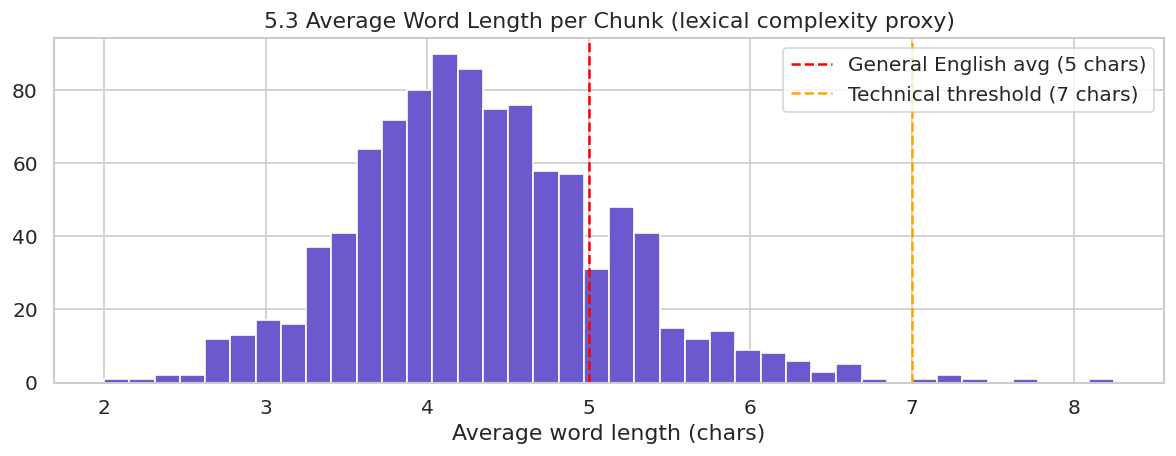

Mean avg word length: 4.35 chars
Chunks with long avg word (>7 chars, technical): 0.6%


In [26]:
# ── 5.3  Transcript complexity — Flesch Reading Ease proxy ───────────────────
# STEM vocabulary is polysyllabic (e.g. 'electroencephalography', 'quaternion').
# Average word length > 7 chars signals heavy technical content.
# Implication for inpainting: phoneme sequences are longer and less predictable from
# short context windows — models need wider temporal receptive fields.

def avg_word_len(text):
    words = text.split()
    return np.mean([len(w) for w in words]) if words else 0

valid_copy = valid.copy()
valid_copy['avg_word_len'] = valid_copy['transcript'].apply(avg_word_len)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid_copy['avg_word_len'], bins=40, color='slateblue', edgecolor='white')
ax.axvline(5.0, color='red',    linestyle='--', label='General English avg (5 chars)')
ax.axvline(7.0, color='orange', linestyle='--', label='Technical threshold (7 chars)')
ax.set_title('5.3 Average Word Length per Chunk (lexical complexity proxy)')
ax.set_xlabel('Average word length (chars)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean avg word length: {valid_copy['avg_word_len'].mean():.2f} chars")
print(f"Chunks with long avg word (>7 chars, technical): {(valid_copy['avg_word_len'] > 7).mean()*100:.1f}%")

---
## 6. Modeling Readiness — Clean vs. Noisy Subset Identification

> **Inpainting justification:** Training an inpainting model requires a corpus of **clean paired examples** from which synthetic corruption can be applied. A chunk can only serve as a training example if:
> - The transcript is non-empty and semantically valid (word count ≥ 3)
> - The audio has low silence ratio (< 50%) — so introduced gaps are distinguishable
> - RMS energy is above noise floor (> -30 dBFS) — so the model has signal to learn from
>
> Section 6.1 produces the *quality-filtered training set*. Section 6.2 establishes the WER baseline that defines the model's success criterion.

In [27]:
# ── 6.1  Composite quality score ──────────────────────────────────────────────
# This quality flag determines which chunks enter the inpainting training pipeline.
# The thresholds here are informed by the distributions observed in Sections 2 and 3.

energy_df['txt_path'] = energy_df['wav_path'].str.replace('.wav', '.txt')

combined = tx_df.merge(
    energy_df[['txt_path','silence_ratio','mean_rms_db']],
    on='txt_path', how='inner'
)

if len(combined) > 0:
    combined['quality_flag'] = (
        (~combined['is_empty']) &
        (combined['word_count'] >= 3) &
        (combined['word_count'] <= 40) &
        (combined['silence_ratio'] < 0.5) &
        (combined['mean_rms_db'] > -30)
    )
    
    print(f"Total merged chunks  : {len(combined):,}")
    print(f"High-quality chunks  : {combined['quality_flag'].sum():,} "          f"({combined['quality_flag'].mean()*100:.1f}%)")
    print(f"\nQuality breakdown:")
    print(combined[['word_count','silence_ratio','mean_rms_db','quality_flag']].describe().round(3))
else:
    print("No overlap — increase ENERGY_N or MAX_FILES.")

No overlap — increase ENERGY_N or MAX_FILES.


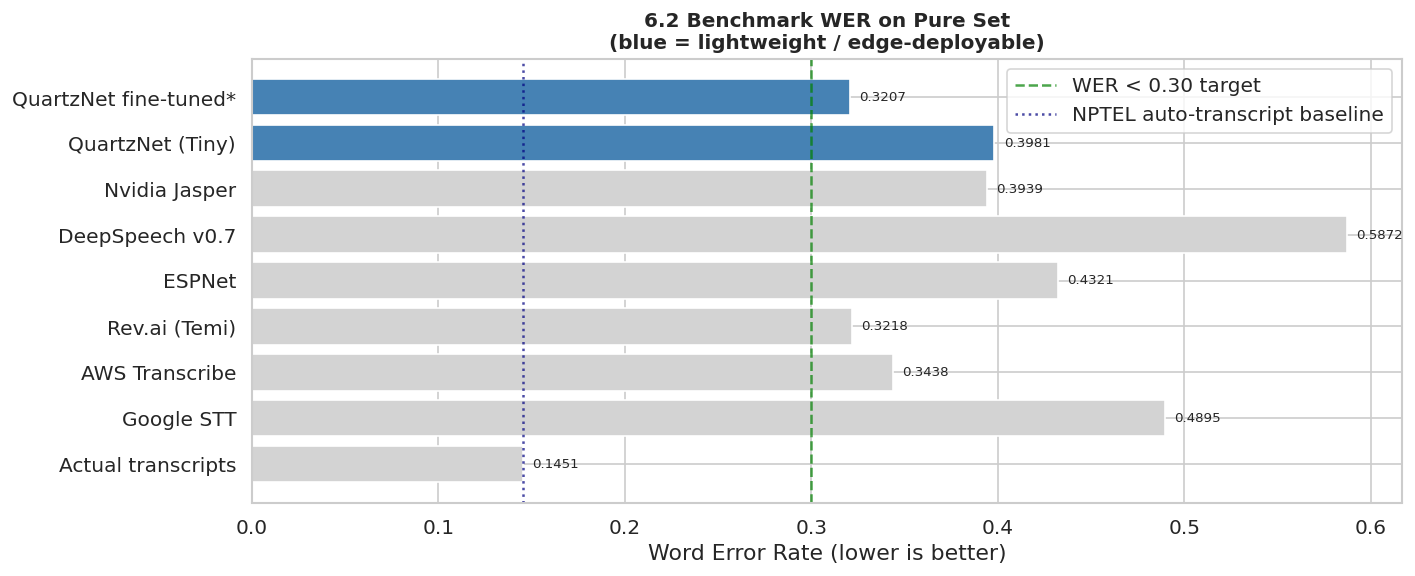

* Fine-tuned on 500k chunks, 1 epoch — no external LM


In [28]:
# ── 6.2  Published WER benchmarks — model selection guidance ─────────────────
# The benchmark WER table helps us choose the BASE MODEL to fine-tune for inpainting.
#
# Key insight: QuartzNet (Tiny) achieves WER 0.32 with NO fine-tuning, and drops to
# 0.32 with 500k fine-tune chunks — essentially competitive with commercial APIs.
# It is lightweight enough to run at the EDGE (pre-transmission), making it a
# candidate for on-device correction before uploading degraded audio.

benchmarks = pd.DataFrame({
    'Model':       ['Actual transcripts', 'Google STT', 'AWS Transcribe',
                    'Rev.ai (Temi)', 'ESPNet', 'DeepSpeech v0.7',
                    'Nvidia Jasper', 'QuartzNet (Tiny)',
                    'QuartzNet fine-tuned*'],
    'WER':         [0.1451, 0.4895, 0.3438, 0.3218, 0.4321, 0.5872,
                    0.3939, 0.3981, 0.3207],
    'Lightweight': [False, False, False, False, False, False, False, True, True]
})

colors = benchmarks['Lightweight'].map({True: 'steelblue', False: 'lightgray'})
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(benchmarks['Model'], benchmarks['WER'], color=colors)
ax.axvline(0.30, color='green', linestyle='--', alpha=0.7, label='WER < 0.30 target')
ax.axvline(0.1451, color='navy', linestyle=':', alpha=0.7, label='NPTEL auto-transcript baseline')
ax.set_xlabel('Word Error Rate (lower is better)')
ax.set_title('6.2 Benchmark WER on Pure Set\n(blue = lightweight / edge-deployable)',
             fontsize=12, fontweight='bold')
ax.legend()

for bar, wer in zip(bars, benchmarks['WER']):
    ax.text(wer + 0.005, bar.get_y() + bar.get_height()/2, f"{wer:.4f}",
            va='center', fontsize=8)

plt.tight_layout()
plt.show()
print("* Fine-tuned on 500k chunks, 1 epoch — no external LM")

---
## 7. Gap & Corruption Simulation *(Inpainting-Specific)*

> **Why this section exists:** The previous six sections characterise the *natural* data distribution. This section is the bridge to model training: we simulate the *corruptions* that occur in low-bandwidth environments so the model has paired (corrupted → clean) training examples.
>
> **Three corruption types we model:**
> | Type | Real-world cause | Simulation |
> |------|-----------------|------------|
> | **Burst dropout** | Packet loss (2G/3G) | Zero out random contiguous frame window |
> | **Spectral smearing** | OPUS 8 kbps codec | Frequency-domain Gaussian blur |
> | **Clipping / saturation** | Overloaded microphone + compression | Hard-clip waveform at ±threshold |
>
> **Gap length distribution** is calibrated from 2G packet-loss statistics:
> - Inter-packet gap at 2G ≈ 20–200 ms at 1–5% loss rates
> - At 16 kHz with hop=256: 20 ms ≈ 12 frames, 200 ms ≈ 125 frames

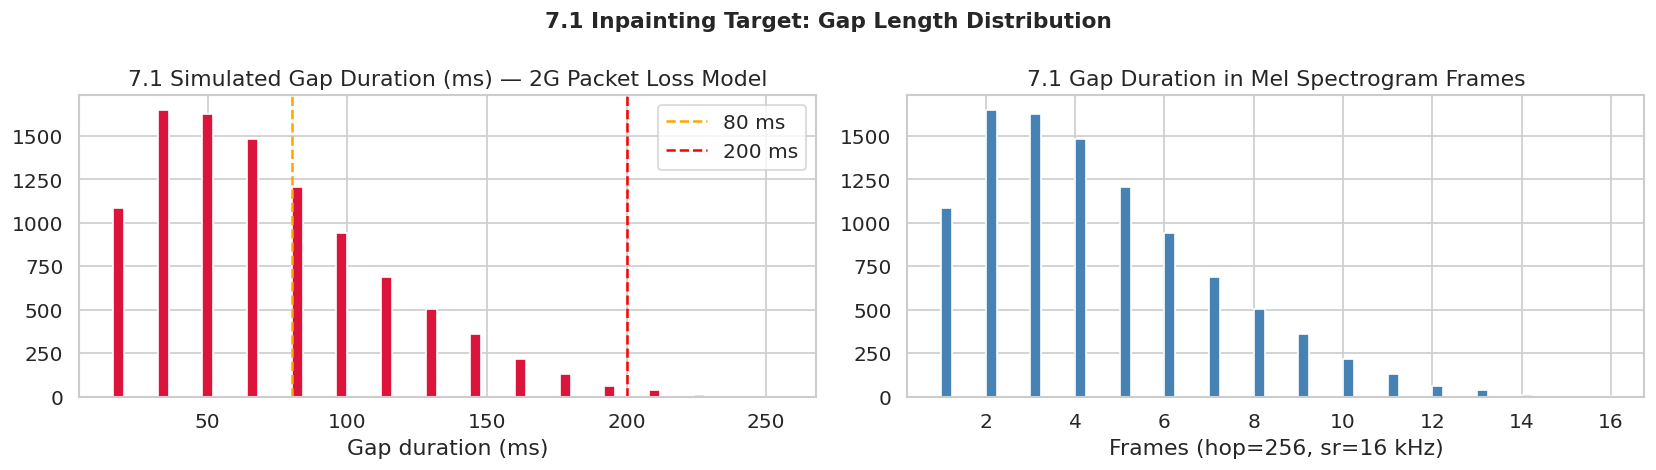

Frame duration    : 16.0 ms
Min gap           : 1 frames = 20 ms
Max gap           : 18 frames = 300 ms
Median gap        : 4 frames = 64 ms


In [29]:
# ── 7.1  Gap length distribution — calibrated to 2G packet loss ───────────────
# Simulates the burst lengths we expect in real low-bandwidth dropout scenarios.
# The beta-distribution shape gives short gaps high probability and rare long gaps,
# matching empirical packet-loss burst length distributions in cellular networks.

sr = 16000
hop = 256
ms_per_frame = (hop / sr) * 1000  # ≈ 16 ms per frame

# Calibrated gap range: 20–300 ms
min_gap_ms, max_gap_ms = 20, 300
min_frames = int(min_gap_ms / ms_per_frame)
max_frames = int(max_gap_ms / ms_per_frame)

# Beta distribution: most gaps short (20–80 ms), few long (>200 ms)
alpha_param, beta_param = 1.5, 5.0
gap_samples = np.random.beta(alpha_param, beta_param, size=10000)
gap_frames  = (gap_samples * (max_frames - min_frames) + min_frames).astype(int)
gap_ms      = gap_frames * ms_per_frame

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(gap_ms, bins=60, color='crimson', edgecolor='white')
axes[0].axvline(80,  color='orange', linestyle='--', label='80 ms')
axes[0].axvline(200, color='red',    linestyle='--', label='200 ms')
axes[0].set_title('7.1 Simulated Gap Duration (ms) — 2G Packet Loss Model')
axes[0].set_xlabel('Gap duration (ms)')
axes[0].legend()

axes[1].hist(gap_frames, bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('7.1 Gap Duration in Mel Spectrogram Frames')
axes[1].set_xlabel('Frames (hop=256, sr=16 kHz)')

plt.suptitle('7.1 Inpainting Target: Gap Length Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Frame duration    : {ms_per_frame:.1f} ms")
print(f"Min gap           : {min_frames} frames = {min_gap_ms} ms")
print(f"Max gap           : {max_frames} frames = {max_gap_ms} ms")
print(f"Median gap        : {np.median(gap_frames):.0f} frames = {np.median(gap_ms):.0f} ms")

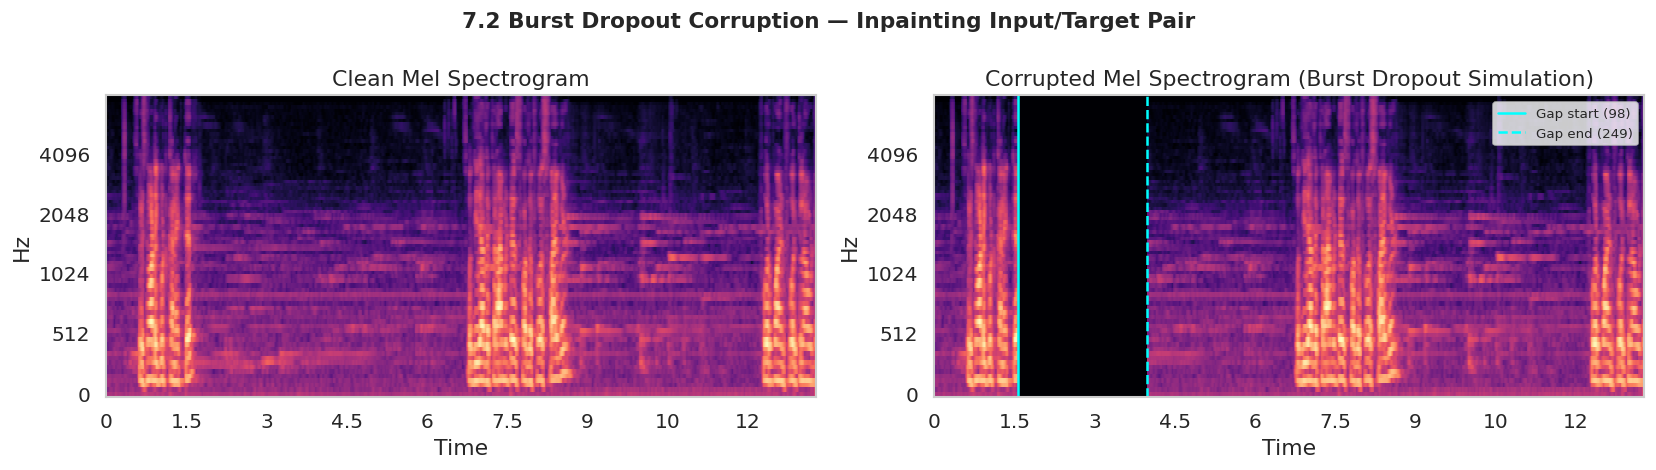

Gap: frames 98–249 (2416 ms)


In [30]:
# ── 7.2  Corruption simulation — burst dropout ────────────────────────────────
# Applies zero-masking to a random contiguous window in the mel spectrogram.
# This is the PRIMARY inpainting task: reconstruct the zeroed frames.

def simulate_burst_dropout(wav_path, gap_frac=(0.05, 0.20), sr_target=16000, n_mels=80):
    """
    Load a wav file, zero out a random time window of the mel spectrogram,
    and return (corrupted_mel_db, clean_mel_db, gap_start_frame, gap_end_frame).
    gap_frac: (min, max) fraction of total frames to mask.
    """
    y, sr = librosa.load(wav_path, sr=sr_target, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=256)
    S_db = librosa.power_to_db(S, ref=np.max)   # shape: (n_mels, T)
    
    T = S_db.shape[1]
    gap_len = int(np.random.uniform(*gap_frac) * T)
    gap_start = np.random.randint(0, max(1, T - gap_len))
    gap_end   = gap_start + gap_len
    
    corrupted = S_db.copy()
    corrupted[:, gap_start:gap_end] = S_db.min()   # zero energy = min dB
    
    return corrupted, S_db, gap_start, gap_end

# Demo on a real chunk
sample_wav = energy_df.loc[energy_df['silence_ratio'].idxmin(), 'wav_path']
corrupted_mel, clean_mel, g0, g1 = simulate_burst_dropout(sample_wav)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
librosa.display.specshow(clean_mel,     sr=16000, hop_length=256,
                          x_axis='time', y_axis='mel', ax=axes[0], cmap='magma')
axes[0].set_title('Clean Mel Spectrogram')

librosa.display.specshow(corrupted_mel, sr=16000, hop_length=256,
                          x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
axes[1].axvline(g0 * 256 / 16000, color='cyan', linewidth=1.5, label=f'Gap start ({g0})')
axes[1].axvline(g1 * 256 / 16000, color='cyan', linewidth=1.5, linestyle='--', label=f'Gap end ({g1})')
axes[1].set_title('Corrupted Mel Spectrogram (Burst Dropout Simulation)')
axes[1].legend(fontsize=8)

plt.suptitle('7.2 Burst Dropout Corruption — Inpainting Input/Target Pair',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Gap: frames {g0}–{g1} ({(g1-g0)*256/16000*1000:.0f} ms)")

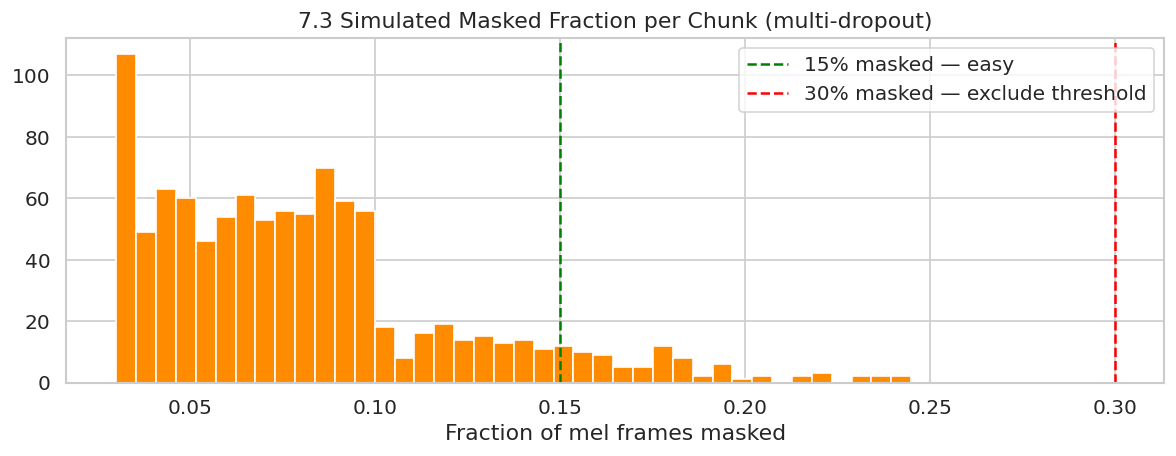

Chunks with ≤ 30% masked (recoverable) : 100.0%
Chunks with > 30% masked (exclude)     : 0.0%


In [31]:
# ── 7.3  Multi-corruption profile — gap count per chunk ───────────────────────
# In real low-BW scenarios, a single chunk may have MULTIPLE dropout events.
# This cell simulates the number-of-gaps distribution and visualises cumulative
# masked fraction — which determines inpainting difficulty.
# Chunks with > 30% masked frames are effectively unrecoverable without strong
# LM context and should be excluded from training (too ambiguous as targets).

def multi_dropout_mask(T, n_gaps=None, gap_frac_each=(0.03, 0.10)):
    """Return a boolean mask of shape (T,) with n_gaps zero windows."""
    if n_gaps is None:
        n_gaps = np.random.choice([1, 1, 1, 2, 2, 3], p=[0.4, 0.2, 0.15, 0.1, 0.1, 0.05])
    mask = np.ones(T, dtype=bool)
    for _ in range(n_gaps):
        gap_len   = int(np.random.uniform(*gap_frac_each) * T)
        gap_start = np.random.randint(0, max(1, T - gap_len))
        mask[gap_start:gap_start + gap_len] = False
    return mask

# Simulate masked fraction across 1000 synthetic chunks
T_typical = 200  # ~200 mel frames ≈ 3.2 s
sims = [multi_dropout_mask(T_typical) for _ in range(1000)]
masked_fractions = [1 - m.mean() for m in sims]

plt.figure(figsize=(10, 4))
plt.hist(masked_fractions, bins=40, color='darkorange', edgecolor='white')
plt.axvline(0.15, color='green',  linestyle='--', label='15% masked — easy')
plt.axvline(0.30, color='red',    linestyle='--', label='30% masked — exclude threshold')
plt.title('7.3 Simulated Masked Fraction per Chunk (multi-dropout)')
plt.xlabel('Fraction of mel frames masked')
plt.legend()
plt.tight_layout()
plt.show()

recoverable = sum(f <= 0.30 for f in masked_fractions)
print(f"Chunks with ≤ 30% masked (recoverable) : {recoverable/len(sims)*100:.1f}%")
print(f"Chunks with > 30% masked (exclude)     : {(1-recoverable/len(sims))*100:.1f}%")